# AI-Based CRISPR gRNA Design and Efficiency Prediction System

## Overview
This project implements an advanced CRISPR-Cas9 guide RNA (gRNA) analysis pipeline.  
It identifies candidate target sites, evaluates sequence features, predicts efficiency,  
and estimates off-target risk.

## Key Features
- PAM site detection (NGG motif for CRISPR-Cas9)
- gRNA extraction (20 bp upstream of PAM)
- GC content and sequence feature analysis
- Rule-based efficiency scoring
- Off-target similarity scoring (Hamming distance)
- Ranking of candidate gRNAs
- Visualization of results

## Methodology
1. Scan DNA sequence for PAM motifs
2. Extract candidate gRNAs
3. Compute sequence-based features
4. Score efficiency based on biological heuristics
5. Evaluate off-target risks
6. Rank and visualize results

## Applications
- Genome editing design
- Functional genomics
- Drug discovery research
- CRISPR experiment planning

## Tech Stack
- Python
- NumPy, Pandas
- Matplotlib

Sequence Length: 56
PAM Sites: [18, 40, 53]
Total gRNAs: 2

Ranked gRNA Candidates:

   Position                  gRNA  GC_Content  PolyT Efficiency  \
0        40  GCTAGCTAGCGTAGCTAGCT        0.55  False       High   
1        53  GCTAGCTAGGCTAGCTAGCT        0.55  False       High   

   Off_Target_Score   A%    T%   G%    C%  
0                 2  0.2  0.25  0.3  0.25  
1                 2  0.2  0.25  0.3  0.25  


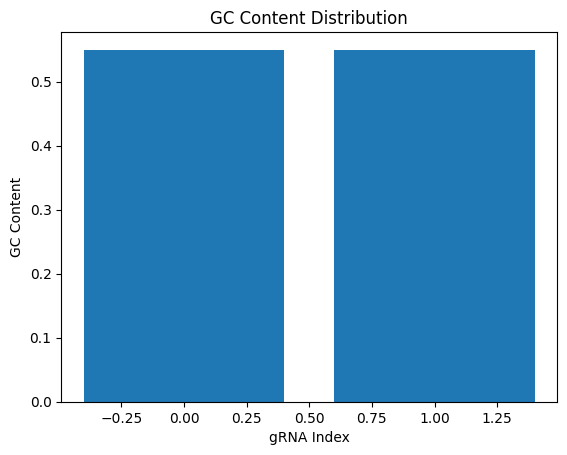

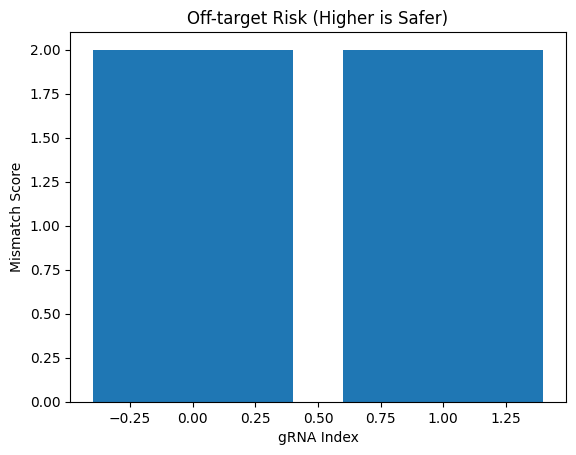


Best gRNA Candidate:
Sequence: GCTAGCTAGCGTAGCTAGCT
Position: 40
GC Content: 0.55
Efficiency: High
Off-target Score: 2

Interpretation:
This guide RNA shows balanced GC content, minimal sequence artifacts, and relatively low off-target similarity, making it a strong candidate for CRISPR-Cas9 targeting.


In [2]:
# ============================================
# Advanced CRISPR gRNA Design Pipeline
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# STEP 1: INPUT DNA SEQUENCE
# ============================================
dna_sequence = "ATGCGTACGTAGCTAGCTAGGCTAGCTAGCGTAGCTAGCTAGGCTAGCTAGCTAGG"

print("Sequence Length:", len(dna_sequence))


# ============================================
# STEP 2: FIND PAM SITES (NGG)
# ============================================
def find_pam_sites(seq):
    return [i for i in range(len(seq)-2) if seq[i+1:i+3] == "GG"]

pam_sites = find_pam_sites(dna_sequence)
print("PAM Sites:", pam_sites)


# ============================================
# STEP 3: EXTRACT gRNA (20 bp upstream)
# ============================================
def extract_grnas(seq, pam_sites, length=20):
    grnas = []
    for site in pam_sites:
        if site >= length:
            grna = seq[site-length:site]
            grnas.append((site, grna))
    return grnas

grnas = extract_grnas(dna_sequence, pam_sites)
print("Total gRNAs:", len(grnas))


# ============================================
# STEP 4: FEATURE CALCULATIONS
# ============================================

def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)

def has_poly_t(seq):
    return "TTTT" in seq

def nucleotide_distribution(seq):
    return {
        "A": seq.count("A") / len(seq),
        "T": seq.count("T") / len(seq),
        "G": seq.count("G") / len(seq),
        "C": seq.count("C") / len(seq)
    }


# ============================================
# STEP 5: EFFICIENCY SCORING (ADVANCED RULES)
# ============================================
def efficiency_score(gc, poly_t):
    score = 0

    # GC balance
    if 0.4 <= gc <= 0.6:
        score += 2
    elif 0.3 <= gc <= 0.7:
        score += 1

    # Penalize poly-T (termination signal)
    if poly_t:
        score -= 2

    if score >= 2:
        return "High"
    elif score == 1:
        return "Medium"
    else:
        return "Low"


# ============================================
# STEP 6: OFF-TARGET ANALYSIS
# ============================================

def hamming_distance(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def off_target_score(grna, all_grnas):
    mismatches = []
    for _, other in all_grnas:
        if grna != other:
            mismatches.append(hamming_distance(grna, other))

    if len(mismatches) == 0:
        return 0

    # Lower mismatch = higher risk
    return min(mismatches)


# ============================================
# STEP 7: ANALYSIS PIPELINE
# ============================================

results = []

for pos, g in grnas:
    gc = gc_content(g)
    poly_t = has_poly_t(g)
    nuc_dist = nucleotide_distribution(g)

    efficiency = efficiency_score(gc, poly_t)
    off_score = off_target_score(g, grnas)

    results.append({
        "Position": pos,
        "gRNA": g,
        "GC_Content": round(gc, 3),
        "PolyT": poly_t,
        "Efficiency": efficiency,
        "Off_Target_Score": off_score,
        "A%": nuc_dist["A"],
        "T%": nuc_dist["T"],
        "G%": nuc_dist["G"],
        "C%": nuc_dist["C"]
    })

df = pd.DataFrame(results)

# Rank by efficiency and off-target safety
df["Efficiency_Score"] = df["Efficiency"].map({"High":3, "Medium":2, "Low":1})
df = df.sort_values(by=["Efficiency_Score", "Off_Target_Score"], ascending=[False, False])

print("\nRanked gRNA Candidates:\n")
print(df.drop(columns=["Efficiency_Score"]))


# ============================================
# STEP 8: VISUALIZATION
# ============================================

if not df.empty:
    plt.figure()
    plt.bar(range(len(df)), df["GC_Content"])
    plt.title("GC Content Distribution")
    plt.xlabel("gRNA Index")
    plt.ylabel("GC Content")
    plt.show()

    plt.figure()
    plt.bar(range(len(df)), df["Off_Target_Score"])
    plt.title("Off-target Risk (Higher is Safer)")
    plt.xlabel("gRNA Index")
    plt.ylabel("Mismatch Score")
    plt.show()


# ============================================
# STEP 9: BEST CANDIDATE INTERPRETATION
# ============================================

if not df.empty:
    best = df.iloc[0]

    print("\nBest gRNA Candidate:")
    print("Sequence:", best["gRNA"])
    print("Position:", best["Position"])
    print("GC Content:", best["GC_Content"])
    print("Efficiency:", best["Efficiency"])
    print("Off-target Score:", best["Off_Target_Score"])

    print("\nInterpretation:")
    print("This guide RNA shows balanced GC content, minimal sequence artifacts, and relatively low off-target similarity, making it a strong candidate for CRISPR-Cas9 targeting.")
else:
    print("No valid gRNAs identified.")